<a href="https://colab.research.google.com/github/ct1224-0rca/Sample01/blob/main/AM%E3%80%80lower_core.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
"""
    hi! im caine! this project has inspired by AM artificial inteligence!
"""

'\n    hi! im caine! this project has inspired by AM artificial inteligence!\n'

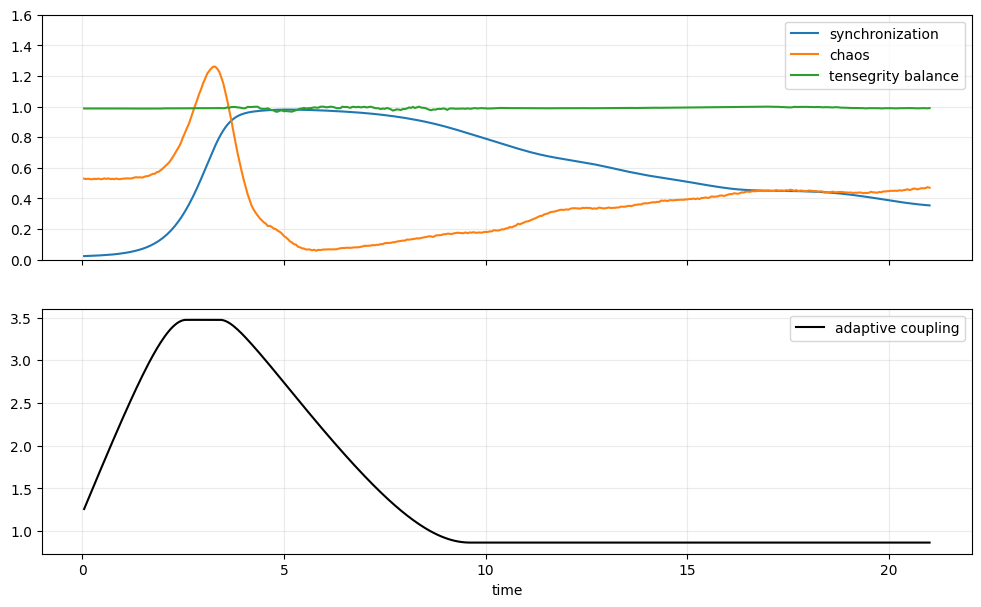

{
  "t": 21.0,
  "sync": 0.354749929745394,
  "chaos": 0.4699512585148276,
  "tension_balance": 0.9900557406654416,
  "positive_pressure": 0.29204734097347773,
  "negative_pressure": 0.3019916003080362,
  "coupling": 0.863970561708051,
  "drive_mean": -0.025199912706188023,
  "action_code": 0,
  "action_label": "IDLE_OBSERVE"
}


In [ ]:
"""
Asemantic Lower Core．

This module implements a small, runnable prototype of the "lower core":
an asemantic physical-signal layer made from Kuramoto synchronization,
positive/negative tensegrity-like balance, and digital homeostasis.
"""

from dataclasses import dataclass, asdict
import json
import math
from typing import Dict, List, Optional

import matplotlib.pyplot as plt
import numpy as np


@dataclass
class LowerCoreConfig:
    n_agents: int = 256
    dt: float = 0.05
    base_coupling: float = 1.2
    noise: float = 0.035
    drive_gain: float = 0.12
    homeostasis_gain: float = 0.18
    target_sync_low: float = 0.34
    target_sync_high: float = 0.82
    seed: int = 7


@dataclass
class CoreSnapshot:
    t: float
    sync: float
    chaos: float
    tension_balance: float
    positive_pressure: float
    negative_pressure: float
    coupling: float
    drive_mean: float
    action_code: int
    action_label: str


class AsemanticLowerCore:
    """A small dynamical core that exposes numeric state for an upper layer."""

    def __init__(self, config: Optional[LowerCoreConfig] = None):
        self.config = config or LowerCoreConfig()
        self.rng = np.random.default_rng(self.config.seed)
        n = self.config.n_agents
        self.t = 0.0
        self.theta = self.rng.uniform(0.0, 2.0 * np.pi, n)
        self.omega = self.rng.normal(0.0, 0.55, n)
        self.drive = self.rng.normal(0.0, 0.15, n)
        self.valence = self.rng.choice([-1.0, 1.0], size=n) * self.rng.uniform(0.25, 1.0, n)
        self.coupling = self.config.base_coupling
        self.last_velocity = np.zeros(n)

    def inject_sensors(self, sensors: Optional[Dict[str, float]]) -> None:
        """Convert sensor numbers into non-linguistic pressure on the core."""
        if not sensors:
            return
        battery = float(sensors.get("battery", 1.0))
        obstacle = float(sensors.get("obstacle", 0.0))
        user_signal = float(sensors.get("user_signal", 0.0))
        network_quality = float(sensors.get("network_quality", 1.0))
        motor_load = float(sensors.get("motor_load", 0.0))

        safety_pressure = (1.0 - battery) * 1.4 + obstacle * 1.8 + motor_load * 0.7
        curiosity_pressure = user_signal * 0.9 + network_quality * 0.25
        pressure = curiosity_pressure - safety_pressure

        mask = self.rng.random(self.config.n_agents) < 0.35
        self.drive[mask] += self.config.drive_gain * pressure * self.valence[mask]

    def order_parameter(self) -> float:
        return float(np.abs(np.mean(np.exp(1j * self.theta))))

    def _homeostasis(self, sync: float, chaos: float) -> None:
        if sync > self.config.target_sync_high:
            self.coupling -= self.config.homeostasis_gain * (sync - self.config.target_sync_high)
            self.drive += self.rng.normal(0.0, self.config.noise * 2.0, self.config.n_agents)
        elif sync < self.config.target_sync_low or chaos > 1.35:
            self.coupling += self.config.homeostasis_gain * (self.config.target_sync_low - min(sync, self.config.target_sync_low))
        self.coupling = float(np.clip(self.coupling, 0.05, 4.0))

    def step(self, sensors: Optional[Dict[str, float]] = None) -> CoreSnapshot:
        c = self.config
        self.inject_sensors(sensors)

        phase_delta = self.theta[None, :] - self.theta[:, None]
        coupling_term = (self.coupling / c.n_agents) * np.sin(phase_delta).sum(axis=1)
        noise = self.rng.normal(0.0, c.noise, c.n_agents)
        velocity = self.omega + coupling_term + c.drive_gain * np.tanh(self.drive) + noise

        self.theta = (self.theta + c.dt * velocity) % (2.0 * np.pi)
        self.drive *= 0.992
        self.t += c.dt
        self.last_velocity = velocity

        sync = self.order_parameter()
        chaos = float(np.std(velocity))
        positive = float(np.mean(np.maximum(np.tanh(self.drive + self.valence), 0.0)))
        negative = float(np.mean(np.maximum(-np.tanh(self.drive + self.valence), 0.0)))
        tension_balance = float(1.0 - min(1.0, abs(positive - negative)))
        self._homeostasis(sync, chaos)

        action_code, action_label = self.map_action(sync, chaos, tension_balance, positive, negative)
        return CoreSnapshot(
            t=round(self.t, 4),
            sync=sync,
            chaos=chaos,
            tension_balance=tension_balance,
            positive_pressure=positive,
            negative_pressure=negative,
            coupling=self.coupling,
            drive_mean=float(np.mean(self.drive)),
            action_code=action_code,
            action_label=action_label,
        )

    @staticmethod
    def map_action(sync: float, chaos: float, balance: float, positive: float, negative: float):
        """Small numeric action table for a robot/app adapter."""
        if chaos > 1.45 or negative - positive > 0.22:
            return 40, "SAFE_STOP_OR_RETREAT"
        if sync > 0.72 and balance > 0.68 and positive >= negative:
            return 30, "COMMIT_FORWARD"
        if sync < 0.30:
            return 20, "EXPLORE_SCAN"
        if balance < 0.52:
            return 10, "WAIT_AND_STABILIZE"
        return 0, "IDLE_OBSERVE"

    def api_state(self, snapshot: CoreSnapshot) -> Dict[str, float]:
        """Payload that can be sent to an upper LLM or Kotlin/Android adapter."""
        return asdict(snapshot)


def run_demo(steps: int = 420, seed: int = 7) -> List[CoreSnapshot]:
    core = AsemanticLowerCore(LowerCoreConfig(seed=seed))
    history = []
    for i in range(steps):
        sensors = {
            "battery": 0.92 - 0.0008 * i,
            "obstacle": 1.0 if 150 < i < 210 else 0.05,
            "user_signal": 0.75 if 260 < i < 340 else 0.15,
            "network_quality": 0.9 if i < 280 else 0.35,
            "motor_load": 0.25 + 0.15 * math.sin(i / 24.0),
        }
        history.append(core.step(sensors))
    return history


def plot_history(history: List[CoreSnapshot]) -> None:
    t = np.array([h.t for h in history])
    sync = np.array([h.sync for h in history])
    chaos = np.array([h.chaos for h in history])
    balance = np.array([h.tension_balance for h in history])
    coupling = np.array([h.coupling for h in history])

    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
    axes[0].plot(t, sync, label="synchronization")
    axes[0].plot(t, chaos, label="chaos")
    axes[0].plot(t, balance, label="tensegrity balance")
    axes[0].set_ylim(0, max(1.6, chaos.max() + 0.1))
    axes[0].legend(loc="upper right")
    axes[0].grid(alpha=0.25)

    axes[1].plot(t, coupling, color="black", label="adaptive coupling")
    axes[1].set_xlabel("time")
    axes[1].legend(loc="upper right")
    axes[1].grid(alpha=0.25)
    plt.show()


if __name__ == "__main__":
    demo = run_demo()
    plot_history(demo)
    print(json.dumps(asdict(demo[-1]), ensure_ascii=False, indent=2))